In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, fbeta_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import joblib
import os

In [11]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

In [12]:
param_grid = {
    "model__C": np.logspace(-3, 2, 6), # log scale search over 10^-3, 10^2, 6 splits: 0.001, 0.01, 0.1, 1, 10, 100. Smaller C = stronger regulisation
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0] # balance between L1 and L2 regulisation
    # if model__penalty : ['elasticnet'], it defaults to l1_ratio = 0.0 hence L2 
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42, solver = "saga", penalty = "elasticnet")) # saga required for elasticnet
    # 2000 iterations to converge reliably accross l1_ratio values
])

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring="roc_auc",
    refit=True,        # refit best model on full training set
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"Best C: {grid_search.best_params_['model__C']}")
print(f"Best l1_ratio: {grid_search.best_params_['model__l1_ratio']}")
print(f"Best AUC-ROC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best C: 0.1
Best l1_ratio: 1.0
Best AUC-ROC: 0.8580


c:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [13]:
# Inspect which features L1 regularization zeroed out entirely
coefficients = best_model.named_steps["model"].coef_[0]  # shape (29,), one weight per feature
feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False)

zeroed_out = coef_df[coef_df["coefficient"] == 0]
kept = coef_df[coef_df["coefficient"] != 0]

print(f"Features zeroed out by L1: {len(zeroed_out)} of {len(feature_names)}\n")
print(zeroed_out["feature"].tolist())

print(f"\nFeatures retained ({len(kept)}), sorted by |coefficient|:")
print(kept.to_string(index=False))

Features zeroed out by L1: 7 of 29

['gender', 'device protection', 'monthly charges', 'internet service_DSL', 'number of subscriptions', 'payment method_Mailed check', 'tenure month type_24 to 48']

Features retained (22), sorted by |coefficient|:
                                 feature  coefficient
                                contract    -0.731412
                              dependents    -0.659524
               tenure month type_0 to 12     0.489621
            internet service_Fiber optic     0.416338
                     internet service_No    -0.293629
                           total charges    -0.228042
         payment method_Electronic check     0.166349
                       paperless billing     0.150577
                        streaming movies     0.149467
                            streaming tv     0.146439
                          multiple lines     0.144606
                         online security    -0.136894
                            tech support    -0.10

      C  l1_ratio  mean_auc_roc  std_auc_roc  mean_train_auc
  0.001      0.00      0.853415     0.010635        0.855254
  0.001      0.25      0.848660     0.009910        0.849471
  0.001      0.50      0.838285     0.008928        0.838431
  0.001      0.75      0.748633     0.017861        0.751581
  0.001      1.00      0.739499     0.003249        0.739512
  0.010      0.00      0.857925     0.011102        0.861311
  0.010      0.25      0.857418     0.011152        0.860642
  0.010      0.50      0.856079     0.011347        0.859114
  0.010      0.75      0.855190     0.011240        0.857471
  0.010      1.00      0.853733     0.011074        0.855362
  0.100      0.00      0.857854     0.011308        0.861802
  0.100      0.25      0.857881     0.011282        0.861798
  0.100      0.50      0.857951     0.011190        0.861784
  0.100      0.75      0.857964     0.011122        0.861726
  0.100      1.00      0.857969     0.011124        0.861648
  1.000      0.00      0

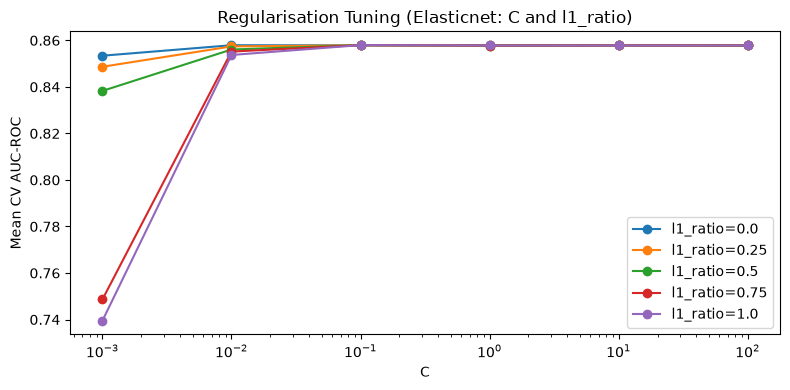

In [14]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[[
    "param_model__C",
    "param_model__l1_ratio",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].copy()

results.columns = ["C", "l1_ratio", "mean_auc_roc", "std_auc_roc", "mean_train_auc"]
results["C"] = results["C"].astype(float)
results = results.sort_values(["C", "l1_ratio"]).reset_index(drop=True)
print(results.to_string(index=False))
 
plt.figure(figsize=(8, 4))
for ratio in sorted(results["l1_ratio"].unique()):
    subset = results[results["l1_ratio"] == ratio]
    plt.plot(subset["C"], subset["mean_auc_roc"], marker="o", label=f"l1_ratio={ratio}")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean CV AUC-ROC")
plt.title("Regularisation Tuning (Elasticnet: C and l1_ratio)")
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\frane\anaconda3\envs\


Threshold chosen by max F1: 0.60
Threshold chosen by max F2: 0.32


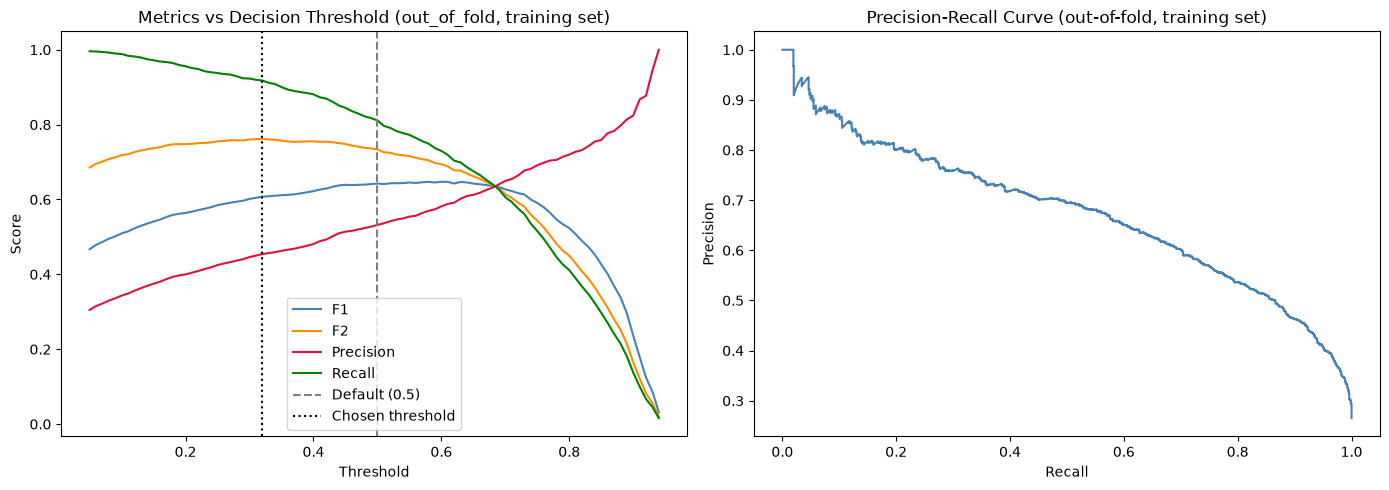

In [15]:
# Originally best model was trained on training data, then called predict_proba on test data and use probabilities to choose threshold, so data leakage.

out_of_fold_probability = cross_val_predict( # for each fold i, trained on other k - 1 folds to predict on fold i
    best_model, X_train, y_train, cv = skf, method = "predict_proba"
)[:, 1] # keeps probability only of positive class 

thresholds = np.arange(0.05, 0.95, 0.01) # 0.05 to 0.94 in steps of 0.01
f1_scores, f2_scores, precisions, recalls = [], [], [], []

for threshold in thresholds:
    prediction = (out_of_fold_probability >= threshold).astype(int)
    f1_scores.append(f1_score(y_train, prediction))

    # fbeta = (1 + beta^2) * (precision * recall)/((beta^2 * precision) + recall), with a beta score of 2, recall is treated 
    # as twice as important as precision
    f2_scores.append(fbeta_score(y_train, prediction, beta = 2))
    precisions.append(precision_score(y_train, prediction))
    recalls.append(recall_score(y_train, prediction))

f1_scores, f2_scores = np.array(f1_scores), np.array(f2_scores)

best_threshold_for_f1 = thresholds[np.argmax(f1_scores)]
best_threshold_for_f2 = thresholds[np.argmax(f2_scores)]

print(f"\nThreshold chosen by max F1: {best_threshold_for_f1:.2f}")
print(f"Threshold chosen by max F2: {best_threshold_for_f2:.2f}")

fig, axis = plt.subplots(1, 2, figsize=(14, 5))
axis[0].plot(thresholds, f1_scores, label="F1", color="steelblue")
axis[0].plot(thresholds, f2_scores, label="F2", color="darkorange") 
axis[0].plot(thresholds, precisions, label="Precision", color="crimson")
axis[0].plot(thresholds, recalls, label="Recall", color="green")
axis[0].axvline(x=0.5, linestyle="--", color="grey", label="Default (0.5)") # vertical line at 0.5, balance between recall and precision for F1
axis[0].axvline(x=best_threshold_for_f2, linestyle=":", color="black", label="Chosen threshold")
axis[0].set_xlabel("Threshold")
axis[0].set_ylabel("Score")
axis[0].set_title("Metrics vs Decision Threshold (out_of_fold, training set)") 
axis[0].legend()
 
precision_curve, recall_curve, _ = precision_recall_curve(y_train, out_of_fold_probability) 
axis[1].plot(recall_curve, precision_curve, color="steelblue")
axis[1].set_xlabel("Recall")
axis[1].set_ylabel("Precision")
axis[1].set_title("Precision-Recall Curve (out-of-fold, training set)")
plt.tight_layout()
plt.show()


Test performance at final threshold: 0.5

AUC-ROC:   0.8461
F1:        0.6281
Precision: 0.5242
Recall:    0.7834

Test performance at final threshold 0.32

AUC-ROC:   0.8461
F1:        0.6009
Precision: 0.4501
Recall:    0.9037


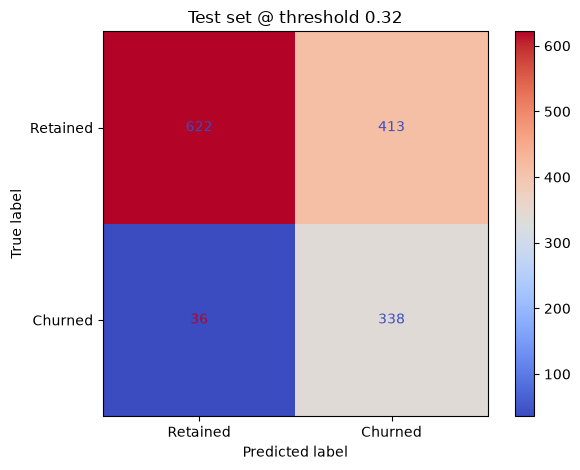

              precision    recall  f1-score   support

    Retained       0.95      0.60      0.73      1035
     Churned       0.45      0.90      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.67      1409
weighted avg       0.81      0.68      0.70      1409



In [ ]:
FINAL_THRESHOLD = best_threshold_for_f2 # f2 better suited for churn prediction than f1

y_initial_probability = best_model.predict_proba(X_test)[:, 1] 
y_initial_prediction = (y_initial_probability >= 0.5).astype(int)
print(f"\nTest performance at final threshold: 0.5\n")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_initial_probability):.4f}") 
print(f"F1:        {f1_score(y_test, y_initial_prediction):.4f}")
print(f"Precision: {precision_score(y_test, y_initial_prediction):.4f}")
print(f"Recall:    {recall_score(y_test, y_initial_prediction):.4f}")


y_test_probability = best_model.predict_proba(X_test)[:, 1]
y_test_prediction = (y_test_probability >= FINAL_THRESHOLD).astype(int)
 
print(f"\nTest performance at final threshold {FINAL_THRESHOLD:.2f}\n")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_test_probability):.4f}") # originally did not use continuous probabilities and just churn prediction
print(f"F1:        {f1_score(y_test, y_test_prediction):.4f}")
print(f"Precision: {precision_score(y_test, y_test_prediction):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_prediction):.4f}")
 
cm = confusion_matrix(y_test, y_test_prediction)
ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm")
plt.title(f"Test set @ threshold {FINAL_THRESHOLD:.2f}")
plt.tight_layout()
plt.show()
 
print(classification_report(y_test, y_test_prediction, target_names=["Retained", "Churned"]))

c:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\frane\anaconda3\envs\

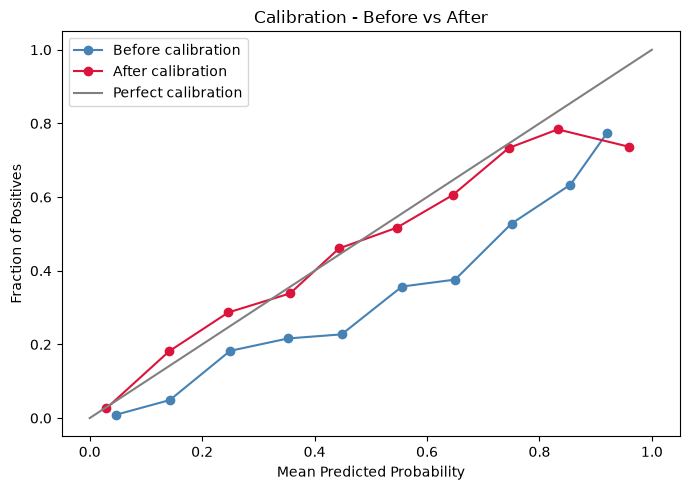

AUC-ROC before calibration: 0.8461
AUC-ROC after calibration:  0.8458


In [17]:
real_probability, predicted_probability = calibration_curve(y_test, y_test_probability, n_bins=10)
 
calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_y_probability = calibrated_model.predict_proba(X_test)[:, 1]
calibrated_real_probability, calibrated_predicted_probability = calibration_curve(
    y_test, calibrated_y_probability, n_bins=10
)
 
plt.figure(figsize=(7, 5))
plt.plot(predicted_probability, real_probability, marker="o", color="steelblue", label="Before calibration")
plt.plot(calibrated_predicted_probability, calibrated_real_probability, marker="o", color="crimson", label="After calibration")
plt.plot([0, 1], [0, 1], color="grey", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration - Before vs After")
plt.legend()
plt.tight_layout()
plt.show()
 
print(f"AUC-ROC before calibration: {roc_auc_score(y_test, y_test_probability):.4f}")
print(f"AUC-ROC after calibration:  {roc_auc_score(y_test, calibrated_y_probability):.4f}")

In [18]:
os.makedirs("../models", exist_ok=True)

# Save threshold, C and l1_ratio to model

joblib.dump(best_model, "../models/logistic_regression.pkl")
joblib.dump(
    {
        "recall_threshold": float(FINAL_THRESHOLD),
        "C": float(grid_search.best_params_["model__C"]),         
        "l1_ratio": float(grid_search.best_params_["model__l1_ratio"]), 
    },
    "../models/thresholds.pkl"
)
 
print("\nModel and thresholds saved.")
print(f"C={grid_search.best_params_['model__C']}, "
      f"l1_ratio={grid_search.best_params_['model__l1_ratio']}, "
      f"threshold={FINAL_THRESHOLD:.2f}")


Model and thresholds saved.
C=0.1, l1_ratio=1.0, threshold=0.32
